In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns

In [ ]:
#Filtrando as colunas que serão utilizadas
dataset = pd.read_csv('saneamento.csv')
colunas_desejadas = ['ano', 'id_municipio','sigla_uf', 'populacao_atendida_agua', 'populacao_atentida_esgoto', 'volume_agua_produzido', 'volume_agua_consumido',]
dados_selecionados = dataset[colunas_desejadas]

#Filtrando colunas e linhas onde os valores não são válidos
dados_filtrados = dados_selecionados.dropna()
dados_filtrados = dados_filtrados[(dados_filtrados != 0).all(axis=1)]

<h1>Primeiro gráfico (população total atendida; água e esgoto)</h1>

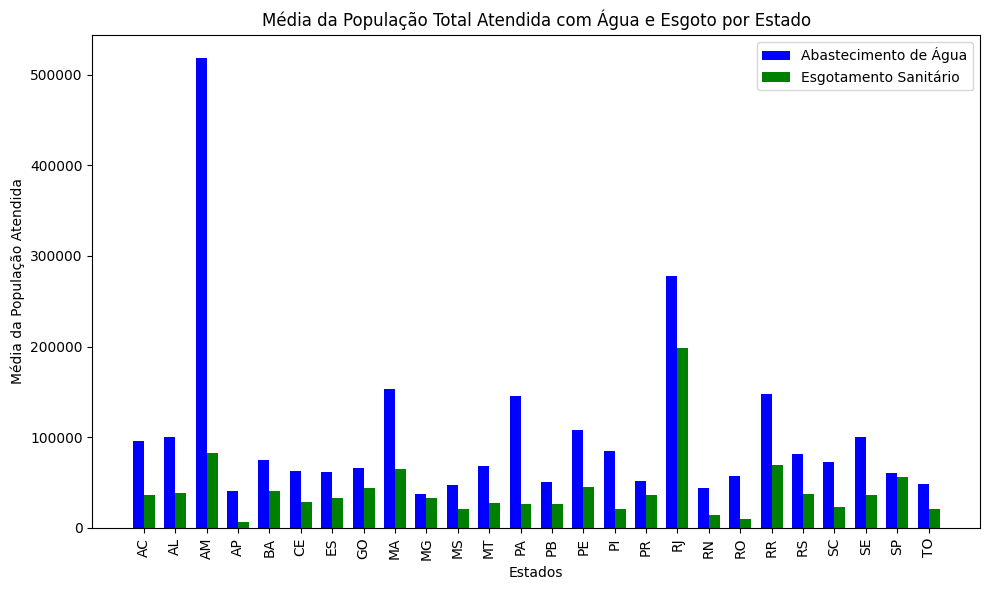

In [ ]:
# Remover o estado DF (Distrito Federal) para esta execução
dados_sem_df = dados_filtrados[dados_filtrados['sigla_uf'] != 'DF']

# Calcular a média da população atendida com água por estado
media_populacao_agua = dados_sem_df.groupby('sigla_uf')['populacao_atendida_agua'].apply(lambda x: np.mean(x))

# Calcular a média da população atendida com esgoto por estado
media_populacao_esgoto = dados_sem_df.groupby('sigla_uf')['populacao_atentida_esgoto'].apply(lambda x: np.mean(x))

# Criar gráfico de barras para as médias
estados = media_populacao_agua.index
largura_barra = 0.35  # Largura das barras

# Posições para as barras de água e esgoto
pos_agua = np.arange(len(estados))
pos_esgoto = [pos + largura_barra for pos in pos_agua]

# Criar o gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(10, 6))

# Barras da população atendida com água
ax.bar(pos_agua, media_populacao_agua, width=largura_barra, label='Abastecimento de Água', color='b')

# Barras da população atendida com esgoto
ax.bar(pos_esgoto, media_populacao_esgoto, width=largura_barra, label='Esgotamento Sanitário', color='g')

# Configurações do gráfico
ax.set_xlabel('Estados')
ax.set_ylabel('Média da População Atendida')
ax.set_title('Média da População Total Atendida com Água e Esgoto por Estado')
ax.set_xticks(pos_agua + largura_barra / 2)
ax.set_xticklabels(estados, rotation=90)
ax.legend()

# Exibir o gráfico
plt.tight_layout()
plt.show()

-Diferença na Cobertura de Serviços: Se em vários estados a população atendida com abastecimento de água é significativamente maior que a atendida com esgotamento sanitário, isso pode indicar uma disparidade na infraestrutura básica. Em muitos casos, o fornecimento de água pode ser priorizado em relação ao esgoto, evidenciando um desequilíbrio nos serviços públicos.

-Desigualdade regional: Alguns estados, como SP (93%) e MG (90%), têm uma alta cobertura de esgotamento sanitário em relação ao abastecimento de água. Já estados como AM (17%) e AP (15%) possuem índices muito baixos, indicando que a maioria da população atendida com água não tem o mesmo acesso ao esgotamento sanitário.


<b><h3>Medidas estatísticas</h3></b>

In [ ]:
# Remover o estado DF (Distrito Federal) para esta execução
dados_sem_df = dados_filtrados[dados_filtrados['sigla_uf'] != 'DF']

# Calcular a média da população atendida com água e esgoto por estado
media_populacao_agua = dados_sem_df.groupby('sigla_uf')['populacao_atendida_agua'].apply(lambda x: np.mean(x))
media_populacao_esgoto = dados_sem_df.groupby('sigla_uf')['populacao_atentida_esgoto'].apply(lambda x: np.mean(x))

# Calcular o índice (porcentagem) de população atendida com esgoto em relação à população atendida com água em cada estado
indice_populacao = (media_populacao_esgoto / media_populacao_agua) * 100

# Calcular a média geral dos índices
media_indice_geral = np.mean(indice_populacao)

# Calcular a mediana geral dos índices
mediana_indice = np.median(indice_populacao)

# Calculo da moda: arredondando os índices para faixas de 10%
faixas_indice = np.round(indice_populacao / 10) * 10
moda_indice = stats.mode(faixas_indice)
print("Moda dos índices (faixa mais comum de cobertura):", moda_indice.mode)

# Calcular o desvio padrão dos índices
desvio_padrao_indice = np.std(indice_populacao)

variacao = np.var(indice_populacao)

# Exibir os resultados
print("Índice de população atendida com esgoto em relação à água (em %) por estado:", indice_populacao)

print("\nMédia geral dos índices:", media_indice_geral)

print("Mediana dos índices:", mediana_indice)



print("\nDesvio padrão dos índices:", desvio_padrao_indice)

print("\nVariação dos índices:", variacao)

# Calcular os quartis dos índices de população atendida com esgotamento sanitário em relação à água
primeiro_quartil = np.quantile(indice_populacao, 0.25)
segundo_quartil = np.quantile(indice_populacao, 0.50)  # Mediana
terceiro_quartil = np.quantile(indice_populacao, 0.75)

print("1º Quartil:", primeiro_quartil)
print("2º Quartil (Mediana):", segundo_quartil)
print("3º Quartil:", terceiro_quartil)

# Calcular o intervalo interquartil
iqr = np.quantile(indice_populacao, 0.75) - np.quantile(indice_populacao, 0.25)

print('Intervalo Interquartil =', iqr)

Índice de população atendida com esgoto em relação à água (em %) por estado: sigla_uf
AC    37.956321
AL    38.116260
AM    16.061880
AP    15.391178
BA    54.281870
CE    45.562896
ES    53.362757
GO    65.700121
MA    42.075316
MG    90.263633
MS    44.121755
MT    40.699809
PA    18.490485
PB    52.370784
PE    42.114989
PI    24.978229
PR    69.043982
RJ    71.262449
RN    33.339088
RO    17.553308
RR    47.155140
RS    46.111754
SC    31.735449
SE    36.149199
SP    92.787990
TO    42.241976
dtype: float64

Média geral dos índices: 44.95879296812241
Mediana dos índices: 42.17848263602055
Moda dos índices (faixa mais comum de cobertura): 40.0

Desvio padrão dos índices: 19.9493927232231

Variação dos índices: 397.97827002538673
1º Quartil: 34.04161578372515
2º Quartil (Mediana): 42.17848263602055
3º Quartil: 53.11476362921091
Intervalo Interquartil = 19.073147845485764


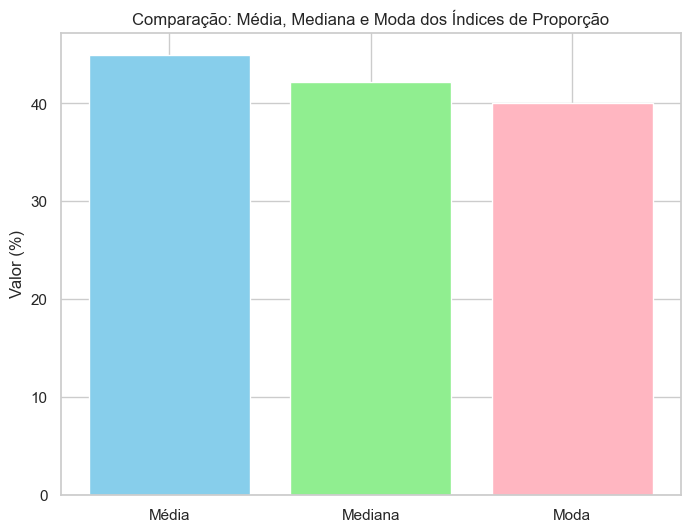

In [ ]:
# Criação de um gráfico de barras
valores = [media_indice_geral, mediana_indice, moda_indice.mode]
labels = ['Média', 'Mediana', 'Moda']

# Configurando o gráfico
plt.figure(figsize=(8,6))
plt.bar(labels, valores, color=['skyblue', 'lightgreen', 'lightpink'])

# Adicionando títulos e rótulos
plt.title('Comparação: Média, Mediana e Moda dos Índices de Proporção')
plt.ylabel('Valor (%)')

# Exibir o gráfico
plt.show()

A média geral dos índices é ~45%, o que significa que, em média, 45% da população atendida com abastecimento de água também é atendida com esgotamento sanitário.
Já a mediana é de ~42%. Então, a média é maior que a mediana, o que indica que há alguns estados com índices de esgotamento sanitário altos e acabam puxando a média geral para cima, já que a média é mais sensível a dados mais altos. Isso sugere que a maioria dos estados está na verdade abaixo da média.
Sobre a moda, separamos os índices por faixas de 10%(0%-10%, 10%-20%,...). A moda de 40 indica que a faixa mais comum de cobertura de entre os estados é de 40%. Isso significa que mais estados têm índices próximos a 40%, reforçando a ideia de que a maioria das regiões possui uma cobertura dos dois serviços.

<b><h3>Gráfico desvio padrão / média</h3></b>

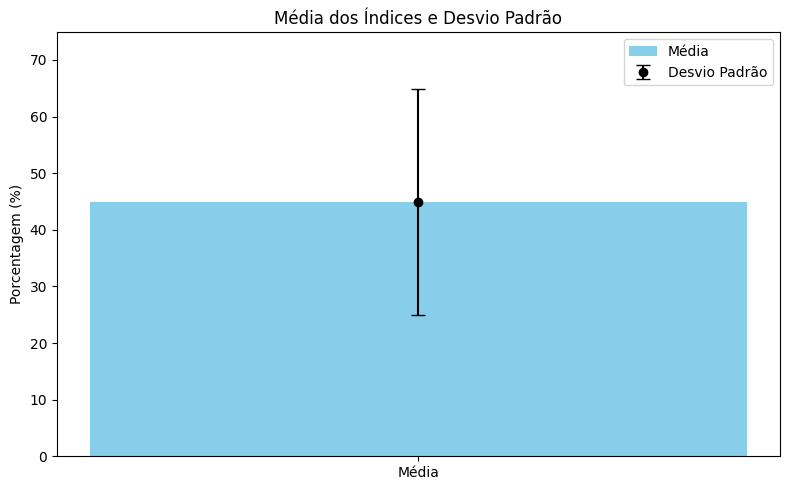

In [ ]:
# Criar um gráfico de barras simples
fig, ax = plt.subplots(figsize=(8, 5))

# Plotar a barra da média
ax.bar('Média', media_indice_geral, color='skyblue', width=0.4, label='Média')

# Adicionar a área do desvio padrão (com linhas superior e inferior)
ax.errorbar('Média', media_indice_geral, yerr=desvio_padrao_indice, fmt='o', color='black', capsize=5, label='Desvio Padrão')

# Configurações do gráfico
ax.set_ylim([0, media_indice_geral + desvio_padrao_indice * 1.5])
plt.title('Média dos Índices e Desvio Padrão')
plt.ylabel('Porcentagem (%)')
plt.legend()

# Exibir o gráfico
plt.tight_layout()
plt.show()

Desvio Padrão: A barra azul representa a média dos índices de esgotamento em relação ao abastecimento de água.
A barra de erro (desvio padrão) mostram a dispersão dos valores ao redor da média. Quanto maior a barra de erro, mais espalhados estão os dados em relação à média. Aqui, no nosso caso, vemos que tem uma variação considerável, porque o desvio padrão foi de 20 com uma média de 45, sugerindo que existe uma grande desigualdade regional entre os estados.


<b><h3>Gráfico dos Quartis</h3></b>

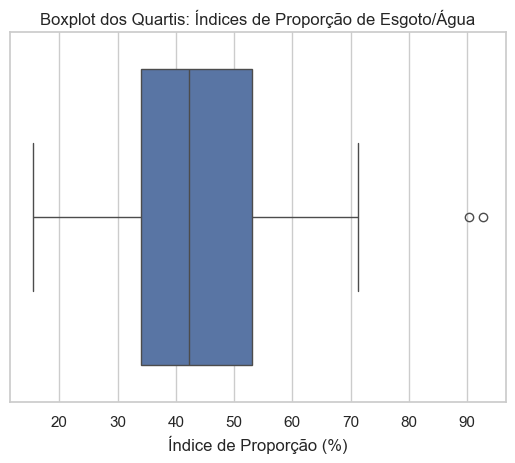

In [ ]:
sns.set_theme(style="whitegrid")

sns.boxplot(x=indice_populacao, whis=1.0)

plt.title('Boxplot dos Quartis: Índices de Proporção de Esgoto/Água')
plt.xlabel('Índice de Proporção (%)')
plt.show()

Quartis: Esse gráfico representa como os dados estão espalhados. Os dados são mais concentrados entre ~36% e ~55%, e a mediana de 42.46% está um pouco abaixo da média, refletindo que a maioria dos estados tem uma cobertura que está abaixo da média, mas não tão baixa quanto o 1º quartil.
1º Quartil: 35.96;
2º Quartil (Mediana): 42.46;
3º Quartil: 55.41;
Intervalo Interquartil = 19.44;  
-Se a linha da mediana está mais próxima da parte inferior ou superior da caixa, isso indica que a distribuição não é simétrica, então teremos aqui uma distribuição assimétrica, com valores mais baixos. As pontas dos bigodes representam os valores mínimos e máximos, respectivamente. E os pontos na direita representam os outliers.



<b><h3>Gráfico com índices do proporção</h3></b>

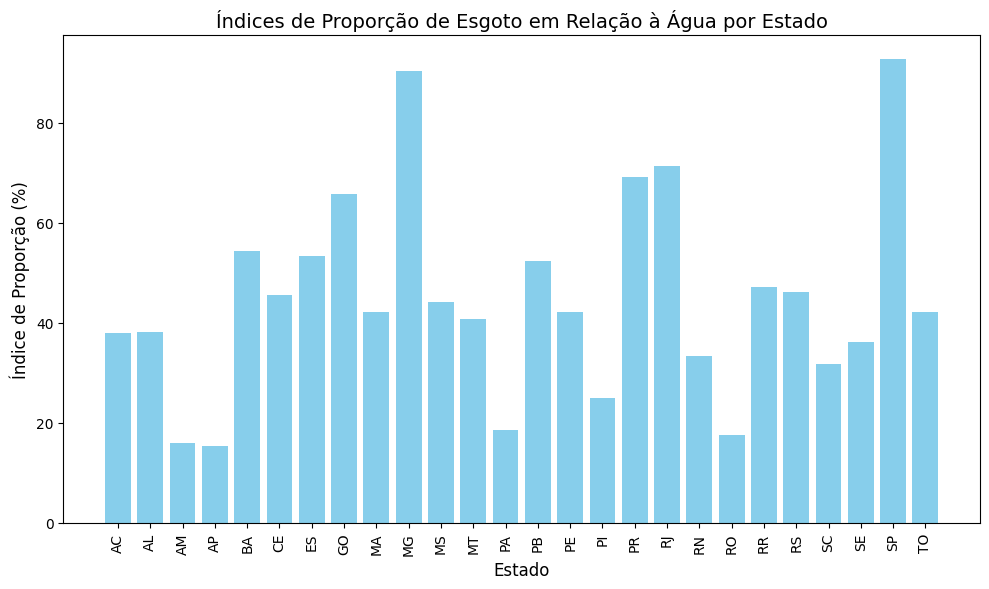

In [ ]:
# Criar o gráfico de barras com os índices de proporção
plt.figure(figsize=(10, 6))
plt.bar(indice_populacao.index, indice_populacao, color='skyblue')

# Adicionar títulos e rótulos
plt.title('Índices de Proporção de Esgoto em Relação à Água por Estado', fontsize=14)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Índice de Proporção (%)', fontsize=12)
plt.xticks(rotation=90)

# Exibir o gráfico
plt.tight_layout()
plt.show()

<h1>(Não concluído)Segundo gráfico (água produzida/consumida)</h1>

<h3>Comparação da média de água produzida e consumida por estado</h3>

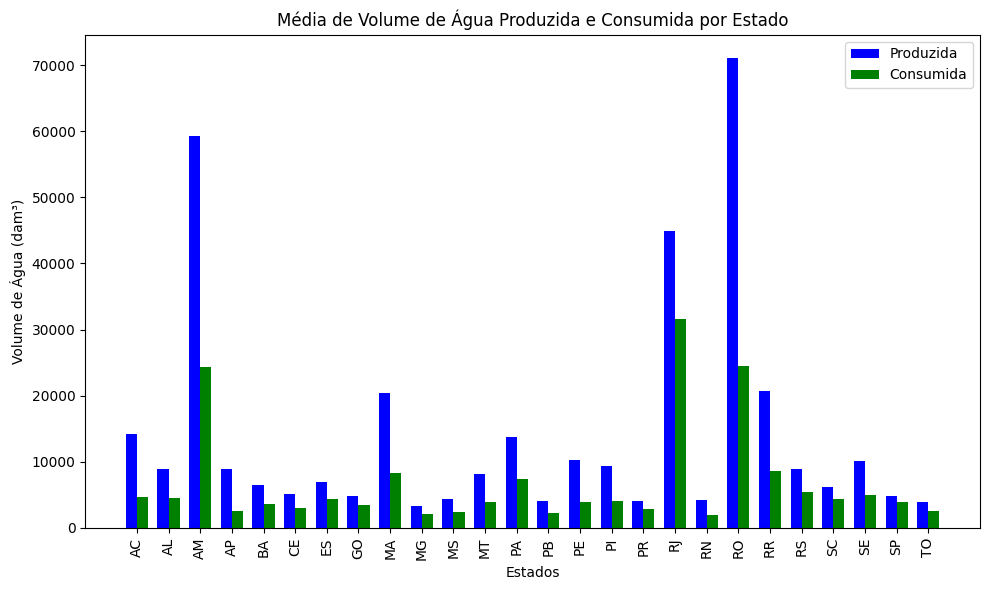

In [ ]:
dados_sem_df = dados_filtrados[dados_filtrados['sigla_uf'] != 'DF']

media_producao = dados_sem_df.groupby('sigla_uf')['volume_agua_produzido'].apply(lambda x: np.mean(x))
media_consumo = dados_sem_df.groupby('sigla_uf')['volume_agua_consumido'].apply(lambda x: np.mean(x))

fig, ax = plt.subplots(figsize=(10, 6))
largura_barra = 0.35
estados = media_producao.index
pos_producao = range(len(estados))
pos_consumo = [pos + largura_barra for pos in pos_producao]

ax.bar(pos_producao, media_producao, width=largura_barra, label='Produzida', color='b')
ax.bar(pos_consumo, media_consumo, width=largura_barra, label='Consumida', color='g')

ax.set_xlabel('Estados')
ax.set_ylabel('Volume de Água (dam³)')
ax.set_title('Média de Volume de Água Produzida e Consumida por Estado')
ax.set_xticks([pos + largura_barra / 2 for pos in pos_producao])
ax.set_xticklabels(estados, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Calcular a média do índice de consumo de água por estado utilizando np.mean()
# media_indice_consumo_agua = dados_filtrados.groupby('sigla_uf')['indice_consumo_agua'].apply(lambda x: np.mean(x))
# print(media_indice_consumo_agua)

# Calcular o índice (porcentagem) de população atendida com esgoto em relação à população atendida com água em cada estado
indice_populacao = (media_consumo / media_producao) * 100

# Calcular a média geral dos índices
media_indice_geral2 = np.mean(indice_populacao)

# Calcular o desvio padrão dos índices
desvio_padrao_indice2 = np.std(indice_populacao)

variancia2 = np.var(indice_populacao)

# Exibir os resultados
print("Índice de população atendida com esgoto em relação a água (em %) por estado:")
print(indice_populacao)

print("\nMédia geral dos índices:")
print(media_indice_geral)

Índice de população atendida com esgoto em relação à água (em %) por estado:
sigla_uf
AC    32.597461
AL    50.184375
AM    41.015881
AP    28.898209
BA    55.219003
CE    59.543065
ES    63.802910
GO    70.880646
MA    41.005983
MG    63.566854
MS    56.653510
MT    47.600621
PA    53.081181
PB    54.176462
PE    38.303693
PI    44.023459
PR    69.482600
RJ    70.252408
RN    45.715271
RO    34.426984
RR    41.497534
RS    60.287139
SC    71.968691
SE    49.661191
SP    82.996968
TO    63.314933
dtype: float64

Média geral dos índices:
44.95879296812241
